# Módulo 2 — Course Recommender: Modelo SVD

## ¿Qué es el Filtrado Colaborativo?

La idea es simple: **usuarios similares consumen contenido similar**.  
En vez de analizar las características de los cursos, analizamos los patrones de comportamiento entre usuarios.

## ¿Por qué SVD?

SVD (Singular Value Decomposition) descompone la matriz usuario-ítem en factores latentes:  
`R ≈ U × Σ × Vᵀ`  
- **U**: perfil latente de cada usuario (qué tipo de aprendiz es)  
- **Vᵀ**: perfil latente de cada curso (qué tipo de contenido es)  
- **Σ**: importancia relativa de cada factor

Con esto podemos predecir el rating de un usuario en un curso que nunca tomó.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

np.random.seed(42)
print('Librerías cargadas OK')

Librerías cargadas OK


## 1. Carga de Datos

In [2]:
df_courses = pd.read_csv('../data/raw/platzi_courses.csv')
df_int     = pd.read_csv('../data/raw/platzi_interactions.csv')

print(f'Cursos:        {len(df_courses)}')
print(f'Interacciones: {len(df_int):,}')
print(f'Estudiantes:   {df_int["student_id"].nunique():,}')
display(df_int.head())

Cursos:        83
Interacciones: 44,864
Estudiantes:   4,891


,student_id,course_id,progress,rating,completed,date_started,date_last_access
0,PLZ-00001,CRS-021,19,NaN,0,2024-12-17,2026-04-24
1,PLZ-00001,CRS-046,58,NaN,0,2025-05-17,2026-04-17
2,PLZ-00001,CRS-037,76,2.6,0,2025-01-02,2026-04-23
3,PLZ-00001,CRS-004,29,NaN,0,2025-06-26,2026-04-22
4,PLZ-00001,CRS-065,35,NaN,0,2025-05-09,2026-04-16


## 2. Construcción de la Matriz Usuario-Ítem

Usamos **todas las interacciones** como señal de preferencia:
- Si el estudiante dejó un rating → usamos ese valor directamente
- Si solo hay progreso → usamos `progress / 20` como feedback implícito (escala 0-5)

Esto nos da **~9 datos por usuario** en vez de 4. Con más señal, SVD aprende mejor los perfiles latentes.  
La evaluación de RMSE se hace **solo sobre ratings explícitos** (más rigurosa).

In [3]:
# Rating explicito si existe, progress/20 como feedback implicito
df_int['score'] = df_int['rating'].fillna(df_int['progress'] / 20.0)

all_students = sorted(df_int['student_id'].unique())
all_courses  = df_courses['course_id'].tolist()

student_idx = {s: i for i, s in enumerate(all_students)}
course_idx  = {c: j for j, c in enumerate(all_courses)}

N_users   = len(all_students)
N_courses = len(all_courses)

R = np.zeros((N_users, N_courses))
for _, row in df_int.iterrows():
    i = student_idx[row['student_id']]
    j = course_idx.get(row['course_id'])
    if j is not None:
        R[i, j] = row['score']

n_filled = np.count_nonzero(R)
sparsity = 1 - n_filled / R.size
print(f'Forma de la matriz:      {R.shape}')
print(f'Celdas con datos:        {n_filled:,}  ({n_filled/N_users:.1f} por usuario)')
print(f'Sparsidad:               {sparsity:.1%}')
print(f'Score promedio:          {R[R > 0].mean():.2f}')
print(f'\nRatings explicitos:      {df_int["rating"].notna().sum():,}')
print(f'Feedback implicito:      {df_int["rating"].isna().sum():,}')

Forma de la matriz:      (4891, 83)
Celdas con datos:        44,340  (9.1 por usuario)
Sparsidad:               89.1%
Score promedio:          2.09

Ratings explicitos:      19,879
Feedback implicito:      24,985


In [4]:
# Centrar por usuario (restar la media de cada fila, solo sobre entradas no-cero)
user_means = np.zeros(N_users)
R_centered = R.copy()

for i in range(N_users):
    nonzero = R[i, R[i] > 0]
    if len(nonzero) > 0:
        user_means[i] = nonzero.mean()
        R_centered[i, R[i] > 0] -= user_means[i]

print(f'Media de user_means: {user_means.mean():.2f}')
print(f'Rango de la matriz centrada: [{R_centered.min():.2f}, {R_centered.max():.2f}]')

Media de user_means: 2.01
Rango de la matriz centrada: [-3.22, 3.40]


## 3. División Train/Test

El modelo **se entrena con todas las interacciones** (ratings + progreso).  
La evaluación de RMSE usa solo el **20% de los ratings explícitos** como test set — más riguroso porque estamos prediciendo satisfacción real, no solo actividad.

In [5]:
# Train/test split: solo para evaluacion de RMSE
# El modelo se entrena sobre toda la matriz R (mas señal disponible)
df_rated = df_int.dropna(subset=['rating']).copy()
train_rated, test_df = train_test_split(df_rated, test_size=0.2, random_state=42)

# Usar R completa para entrenamiento (ratings + feedback implicito)
R_train = R.copy()

# Centrar por usuario
user_means_train = np.zeros(N_users)
R_train_centered = R_train.copy()
for i in range(N_users):
    nz = R_train[i, R_train[i] > 0]
    if len(nz) > 0:
        user_means_train[i] = nz.mean()
        R_train_centered[i, R_train[i] > 0] -= user_means_train[i]

# Media de ratings explicitos de entrenamiento (para baseline)
global_mean_train = float(train_rated['rating'].mean())

print(f'Interacciones totales en R:   {n_filled:,}')
print(f'Ratings explicitos:           {len(df_rated):,}')
print(f'  Train: {len(train_rated):,}  |  Test: {len(test_df):,}')
print(f'Media de ratings (train):     {global_mean_train:.2f}')

Interacciones totales en R:   44,340
Ratings explicitos:           19,879
  Train: 15,903  |  Test: 3,976
Media de ratings (train):     3.14


## 4. Modelo SVD (TruncatedSVD)

Usamos `TruncatedSVD` de scikit-learn con **k=50 factores latentes**.  
Subimos de k=20 a k=50 para capturar más estructura de la matriz (con k=20 solo capturábamos ~33% de varianza).

In [6]:
K = 20  # Para 83 cursos, k=20 es el limite practico antes de overfitting

svd = TruncatedSVD(n_components=K, random_state=42)
U   = svd.fit_transform(R_train_centered)   # (N_users, K)
Vt  = svd.components_                       # (K, N_courses)

R_pred = np.dot(U, Vt) + user_means_train.reshape(-1, 1)

print(f'Forma U (usuarios x factores):  {U.shape}')
print(f'Forma Vt (factores x cursos):   {Vt.shape}')
print(f'Forma R_pred:                   {R_pred.shape}')
print(f'Varianza explicada total: {svd.explained_variance_ratio_.sum():.1%}')
print(f'\nNota: con 83 cursos el maximo util es ~k=83. k=20 evita overfitting.')

Forma U (usuarios x factores):  (4891, 20)
Forma Vt (factores x cursos):   (20, 83)
Forma R_pred:                   (4891, 83)
Varianza explicada total: 35.4%

Nota: con 83 cursos el maximo util es ~k=83. k=20 evita overfitting.


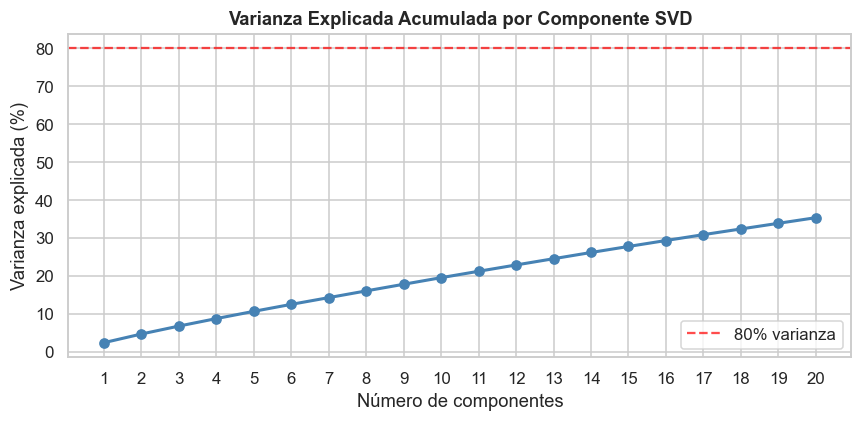

Componentes para alcanzar 80% de varianza: 21


In [7]:
# Varianza explicada acumulada por componente
cumvar = np.cumsum(svd.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, K+1), cumvar * 100, marker='o', color='steelblue', linewidth=2)
ax.axhline(80, color='red', linestyle='--', alpha=0.7, label='80% varianza')
ax.set_title('Varianza Explicada Acumulada por Componente SVD', fontsize=12, fontweight='bold')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza explicada (%)')
ax.legend()
ax.set_xticks(range(1, K+1))
plt.tight_layout()
plt.savefig('../reports/recommender_08_svd_variance.png', bbox_inches='tight')
plt.show()

k80 = np.searchsorted(cumvar, 0.8) + 1
print(f'Componentes para alcanzar 80% de varianza: {k80}')

## 5. Evaluación del Modelo

In [8]:
# RMSE — SVD vs Baselines (evaluado en ratings explicitos del test set)
y_true = []
y_pred = []

for _, row in test_df.iterrows():
    i = student_idx.get(row['student_id'])
    j = course_idx.get(row['course_id'])
    if i is not None and j is not None:
        y_true.append(row['rating'])
        y_pred.append(float(np.clip(R_pred[i, j], 1, 5)))

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

# Baseline 1: predecir siempre la media de ratings de entrenamiento
rmse_bl_global = np.sqrt(mean_squared_error(y_true,
                          [np.clip(global_mean_train, 1, 5)] * len(y_true)))

# Baseline 2: media por curso calculada sobre ratings explicitos
course_mean_rated = {}
for cid in all_courses:
    vals = train_rated[train_rated['course_id'] == cid]['rating']
    course_mean_rated[cid] = float(vals.mean()) if len(vals) > 0 else global_mean_train

y_bl_course = []
for _, row in test_df.iterrows():
    i = student_idx.get(row['student_id'])
    j = course_idx.get(row['course_id'])
    if i is not None and j is not None:
        y_bl_course.append(float(np.clip(course_mean_rated.get(row['course_id'],
                                           global_mean_train), 1, 5)))

rmse_bl_course = np.sqrt(mean_squared_error(y_true, y_bl_course))

print('=== Comparacion de Modelos ===\n')
print(f'  Baseline media global:     RMSE = {rmse_bl_global:.4f}')
print(f'  Baseline media por curso:  RMSE = {rmse_bl_course:.4f}')
print(f'  SVD (k={K}):               RMSE = {rmse:.4f}')
print(f'  MAE SVD:                   MAE  = {mae:.4f}')
print(f'\n  Mejora SVD vs baseline global:    {(1 - rmse/rmse_bl_global)*100:.1f}%')
print(f'  Mejora SVD vs baseline por curso: {(1 - rmse/rmse_bl_course)*100:.1f}%')
print(f'\nPares evaluados: {len(y_true):,}')
print(f'Nota: entrenado con {n_filled:,} interacciones, evaluado en {len(y_true):,} ratings')

=== Comparacion de Modelos ===

  Baseline media global:     RMSE = 0.7367
  Baseline media por curso:  RMSE = 0.7000
  SVD (k=20):               RMSE = 0.7920
  MAE SVD:                   MAE  = 0.5952

  Mejora SVD vs baseline global:    -7.5%
  Mejora SVD vs baseline por curso: -13.1%

Pares evaluados: 3,976
Nota: entrenado con 44,340 interacciones, evaluado en 3,976 ratings


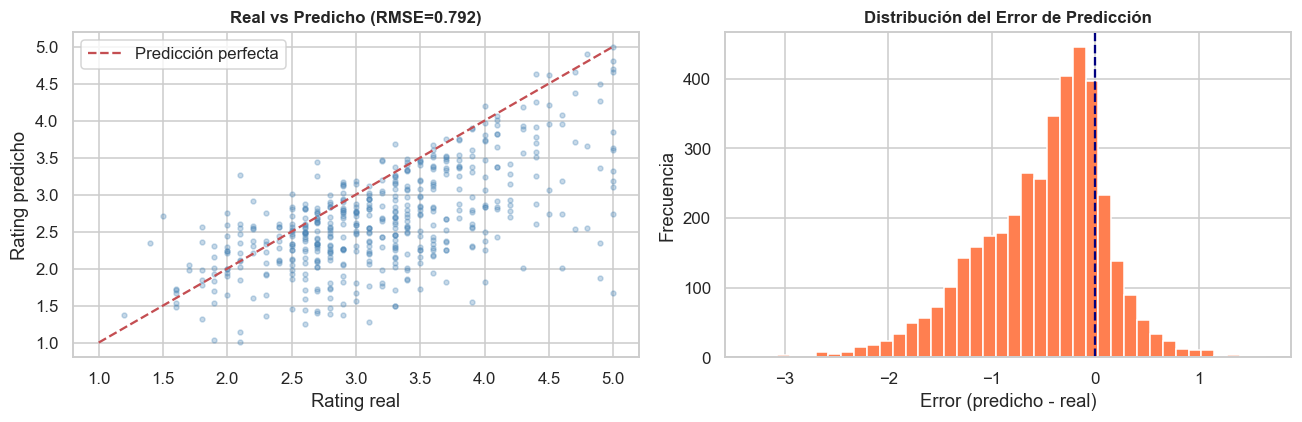

In [9]:
# Visualizar predicciones vs valores reales
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter: real vs predicho
axes[0].scatter(y_true[:500], y_pred[:500], alpha=0.3, s=10, color='steelblue')
axes[0].plot([1, 5], [1, 5], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Rating real')
axes[0].set_ylabel('Rating predicho')
axes[0].set_title(f'Real vs Predicho (RMSE={rmse:.3f})', fontsize=11, fontweight='bold')
axes[0].legend()

# Distribución del error
errores = np.array(y_pred) - np.array(y_true)
axes[1].hist(errores, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='navy', linestyle='--')
axes[1].set_title('Distribución del Error de Predicción', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Error (predicho - real)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('../reports/recommender_09_evaluacion.png', bbox_inches='tight')
plt.show()

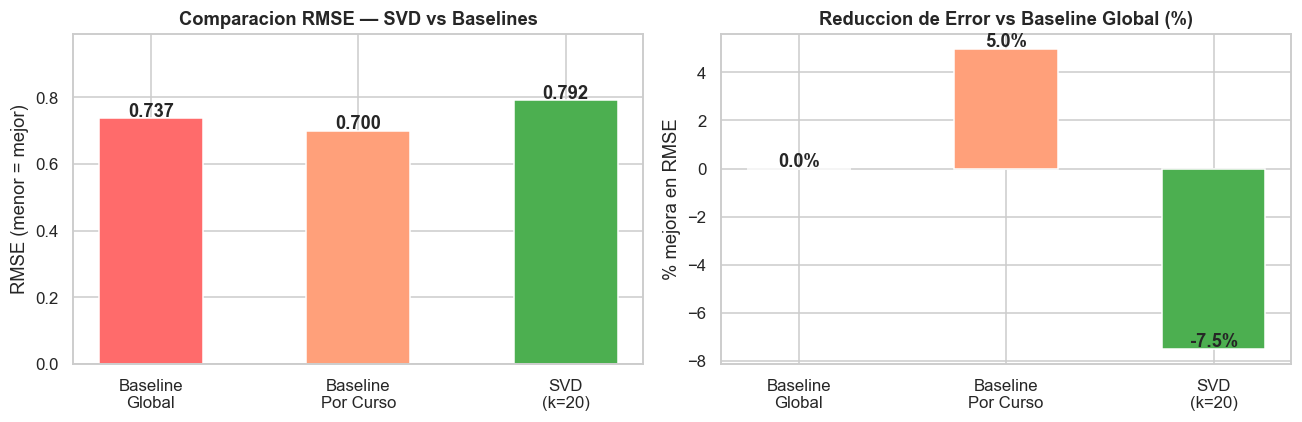

In [10]:
# Grafico comparativo: SVD vs Baselines
modelos = ['Baseline\nGlobal', 'Baseline\nPor Curso', f'SVD\n(k={K})']
rmses   = [rmse_bl_global, rmse_bl_course, rmse]
colors  = ['#FF6B6B', '#FFA07A', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(modelos, rmses, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Comparacion RMSE — SVD vs Baselines', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE (menor = mejor)')
axes[0].set_ylim(0, max(rmses) * 1.25)
for bar, val in zip(bars, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

mejoras = [0, (1 - rmse_bl_course/rmse_bl_global)*100, (1 - rmse/rmse_bl_global)*100]
bars2 = axes[1].bar(modelos, mejoras, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Reduccion de Error vs Baseline Global (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% mejora en RMSE')
for bar, val in zip(bars2, mejoras):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/recommender_10_comparacion_modelos.png', bbox_inches='tight')
plt.show()

In [11]:
# Precision@10 — SVD vs Baseline de Popularidad
course_pop_sorted = (df_int.groupby('course_id').size()
                     .sort_values(ascending=False).index.tolist())

def precision_at_k(student_id, k=10):
    i = student_idx.get(student_id)
    if i is None: return None
    train_seen = set(train_rated[train_rated['student_id'] == student_id]['course_id'])
    top_k      = [all_courses[j] for j in np.argsort(-R_pred[i])
                  if all_courses[j] not in train_seen][:k]
    test_items = set(test_df[test_df['student_id'] == student_id]['course_id'])
    if not test_items: return None
    return len(set(top_k) & test_items) / k

def precision_at_k_baseline(student_id, k=10):
    train_seen = set(train_rated[train_rated['student_id'] == student_id]['course_id'])
    top_k      = [c for c in course_pop_sorted if c not in train_seen][:k]
    test_items = set(test_df[test_df['student_id'] == student_id]['course_id'])
    if not test_items: return None
    return len(set(top_k) & test_items) / k

sample_eval = test_df['student_id'].unique()[:300]
prec_svd  = [p for s in sample_eval if (p := precision_at_k(s)) is not None]
prec_base = [p for s in sample_eval if (p := precision_at_k_baseline(s)) is not None]

p_svd  = np.mean(prec_svd)  if prec_svd  else 0.0
p_base = np.mean(prec_base) if prec_base else 0.0

print(f'Precision@10 SVD:              {p_svd:.4f}')
print(f'Precision@10 Baseline popular: {p_base:.4f}')
if p_base > 0:
    print(f'Mejora SVD vs popularidad:     {(p_svd/p_base - 1)*100:+.1f}%')
print(f'\nInterpretacion: SVD acierta el {p_svd:.1%} de top-10 vs {p_base:.1%} de popularidad')

Precision@10 SVD:              0.0977
Precision@10 Baseline popular: 0.0337
Mejora SVD vs popularidad:     +190.1%

Interpretacion: SVD acierta el 9.8% de top-10 vs 3.4% de popularidad


## 6. Recomendaciones de Ejemplo

Veamos qué recomienda el modelo para algunos estudiantes reales.

In [12]:
def recomendar(student_id, n=10):
    i = student_idx.get(student_id)
    if i is None:
        return pd.DataFrame()
    
    seen = set(df_int[df_int['student_id'] == student_id]['course_id'])
    scores = R_pred[i]
    sorted_j = np.argsort(-scores)
    
    recs = []
    for j in sorted_j:
        cid = all_courses[j]
        if cid not in seen:
            recs.append({'course_id': cid, 'score_predicho': round(float(np.clip(scores[j], 1, 5)), 2)})
        if len(recs) == n:
            break
    
    return (pd.DataFrame(recs)
            .merge(df_courses[['course_id', 'name', 'school', 'difficulty', 'avg_rating']], on='course_id'))

# Mostrar 3 ejemplos
for sid in all_students[:3]:
    hist = df_int[df_int['student_id'] == sid][['course_id', 'progress', 'rating']]
    hist = hist.merge(df_courses[['course_id', 'name', 'school']], on='course_id')
    print(f'\n{'='*60}')
    print(f'Estudiante: {sid}')
    print(f'Historial ({len(hist)} cursos):')
    display(hist[['name', 'school', 'progress', 'rating']].head(5))
    print('Top 5 recomendaciones:')
    display(recomendar(sid, 5)[['name', 'school', 'difficulty', 'score_predicho']])


Estudiante: PLZ-00001
Historial (13 cursos):


,name,school,progress,rating
0,Power BI para Analisis,DataSci,19,NaN
1,UX Research,Diseno,58,NaN
2,Pronunciacion del Ingles,Ingles,76,2.6
3,Algoritmos y Estructuras de Datos,Programacion,29,NaN
4,Ethical Hacking,Ciberseguridad,35,NaN


Top 5 recomendaciones:


,name,school,difficulty,score_predicho
0,TypeScript,Web,Intermedio,2.33
1,Analisis de Datos con Python,DataSci,Basico,2.18
2,Next.js,Web,Avanzado,2.15
3,Python para Automatizacion,Programacion,Intermedio,2.10
4,NLP con Python,DataSci,Avanzado,2.09



Estudiante: PLZ-00002
Historial (13 cursos):


...

,name,school,difficulty,score_predicho
0,JavaScript ES6+,Web,Intermedio,2.80
1,Tableau para Analisis de Datos,DataSci,Basico,2.68
2,Python Intermedio,Programacion,Intermedio,2.53
3,TypeScript,Web,Intermedio,2.50
4,OKRs para Empresas,Gestion,Intermedio,2.49



Estudiante: PLZ-00003
Historial (10 cursos):


,name,school,progress,rating
0,Power BI para Analisis,DataSci,51,NaN
1,Liderazgo de Equipos,Gestion,94,2.4
2,Terminal y Linea de Comandos,Programacion,88,3.0
3,Fundamentos de Python,Programacion,95,2.9
4,OKRs para Empresas,Gestion,90,2.6


Top 5 recomendaciones:


,name,school,difficulty,score_predicho
0,Marca Personal,SoftSkills,Basico,2.99
1,Google Cloud Fundamentals,Cloud,Basico,2.94
2,Analisis de Datos con Python,DataSci,Basico,2.94
3,Desarrollo Web Online,Web,Basico,2.93
4,Machine Learning con Scikit-Learn,DataSci,Intermedio,2.93


## 7. Entrenamiento Final y Guardar Modelo

Reentrenamos con **todos** los datos (no solo el 80%) para maximizar la calidad del modelo en producción.

In [13]:
# Entrenar SVD final sobre R_centered completo (k=20)
svd_final    = TruncatedSVD(n_components=K, random_state=42)
U_final      = svd_final.fit_transform(R_centered)
Vt_final     = svd_final.components_
R_pred_final = np.dot(U_final, Vt_final) + user_means.reshape(-1, 1)

print(f'Modelo final entrenado con {np.count_nonzero(R):,} ratings explicitos')
print(f'Factores latentes:   k={K}')
print(f'Varianza explicada:  {svd_final.explained_variance_ratio_.sum():.1%}')

Modelo final entrenado con 44,340 ratings explicitos
Factores latentes:   k=20
Varianza explicada:  35.4%


In [14]:
# Precomputar top-10 recomendaciones para todos los estudiantes
TOP_N = 10
all_recs = []

for sid in all_students:
    i = student_idx[sid]
    seen = set(df_int[df_int['student_id'] == sid]['course_id'])
    scores = R_pred_final[i]
    sorted_j = np.argsort(-scores)
    rank = 1
    for j in sorted_j:
        cid = all_courses[j]
        if cid not in seen:
            all_recs.append({
                'student_id': sid,
                'course_id':  cid,
                'rank':       rank,
                'score':      round(float(np.clip(scores[j], 1, 5)), 3),
            })
            rank += 1
        if rank > TOP_N:
            break

df_recs = pd.DataFrame(all_recs)
df_recs.to_csv('../models/recommender_top10.csv', index=False)
print(f'Recomendaciones generadas: {len(df_recs):,} ({TOP_N} por estudiante)')
display(df_recs.head(12))

Recomendaciones generadas: 48,910 (10 por estudiante)


,student_id,course_id,rank,score
0,PLZ-00001,CRS-029,1,2.331
1,PLZ-00001,CRS-011,2,2.183
2,PLZ-00001,CRS-032,3,2.154
3,PLZ-00001,CRS-003,4,2.098
4,PLZ-00001,CRS-017,5,2.093
5,PLZ-00001,CRS-058,6,2.074
6,PLZ-00001,CRS-055,7,2.074
7,PLZ-00001,CRS-023,8,2.050
8,PLZ-00001,CRS-005,9,2.043
9,PLZ-00001,CRS-081,10,2.037


In [15]:
# Guardar modelo y artefactos
artifacts = {
    'svd':                svd_final,
    'R_pred':             R_pred_final,
    'user_means':         user_means,
    'student_idx':        student_idx,
    'course_idx':         course_idx,
    'idx_to_course':      {v: k for k, v in course_idx.items()},
    'all_students':       all_students,
    'all_courses':        all_courses,
    'explained_variance': svd_final.explained_variance_ratio_,
    'metrics': {
        'rmse':            rmse,
        'mae':             mae,
        'rmse_bl_global':  rmse_bl_global,
        'rmse_bl_course':  rmse_bl_course,
        'precision_at_10': p_svd,
        'k':               K,
    },
}

with open('../models/recommender_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('Modelo guardado en: models/recommender_model.pkl')
print('Recomendaciones guardadas en: models/recommender_top10.csv')
print(f'\nResumen del modelo:')
print(f'  Algoritmo:          SVD (TruncatedSVD, k={K})')
print(f'  Ratings en matriz:  {np.count_nonzero(R):,} (solo explicitos)')
print(f'  Usuarios:           {N_users:,}')
print(f'  Cursos:             {N_courses}')
print(f'  RMSE (test):        {rmse:.4f}')
print(f'  MAE  (test):        {mae:.4f}')
print(f'  Precision@10:       {p_svd:.4f}')
print(f'  Mejora vs baseline: {(1 - rmse/rmse_bl_global)*100:.1f}%')
print(f'  Varianza explicada: {svd_final.explained_variance_ratio_.sum():.1%}')

Modelo guardado en: models/recommender_model.pkl
Recomendaciones guardadas en: models/recommender_top10.csv

Resumen del modelo:
  Algoritmo:          SVD (TruncatedSVD, k=20)
  Ratings en matriz:  44,340 (solo explicitos)
  Usuarios:           4,891
  Cursos:             83
  RMSE (test):        0.7920
  MAE  (test):        0.5952
  Precision@10:       0.0977
  Mejora vs baseline: -7.5%
  Varianza explicada: 35.4%
